In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import sklearn.metrics as skm
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as skm

try:
    import catboost as cb
except:
    ! pip install catboost

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
int_n_constants = 1000

Project: 20231010-gen-xii
Task: ad_hoc


### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Load in data

In [5]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}_noleaks_pre.gzip'
    str_uri = f's3://{str_project}/03_pricing_lgd/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
    df = pd.read_parquet(str_uri)
    df['data_set'] = str_df
    list_df.append(df)
df = pd.concat(list_df)
# this is where you will subset to ...
df

100%|██████████| 3/3 [00:04<00:00,  1.35s/it]


,linkf189__tu,linkf060__tu,linkf045__tu,linkb012__tu,intservicecontractmileage__app,intservicecontractterm__app,linkf185__tu,linkf105__tu,linkf193__tu,linkf195__tu,...,data_set,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target
8202,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8203,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,train,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929
8204,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8205,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,train,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463
8206,769.0,0.0,0.0,0.0,120000.0,0.0,5.0,5.0,5.0,1802.0,...,train,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1540.0,0.0,0.0,0.0,120000.0,0.0,658.0,658.0,658.0,1601.0,...,test,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335
2335,48.0,0.0,0.0,0.0,120000.0,0.0,244.0,48.0,48.0,1358.0,...,test,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968
5274,1493.0,0.0,0.0,0.0,120000.0,0.0,1488.0,1488.0,1488.0,1493.0,...,test,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606
6464,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,...,test,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134


### Get LGD predictions

In [6]:
# get gen 12 LGD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['yhat'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,linkf189__tu,linkf060__tu,linkf045__tu,linkb012__tu,intservicecontractmileage__app,intservicecontractterm__app,linkf185__tu,linkf105__tu,linkf193__tu,linkf195__tu,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,yhat
8202,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.435195
8203,40.0,0.0,0.0,0.0,0.0,24.0,152.0,40.0,40.0,1141.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,-0.097929,0.419317
8204,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463,0.363815
8205,0.0,0.0,0.0,0.0,100000.0,48.0,0.0,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,0.464463,0.346931
8206,769.0,0.0,0.0,0.0,120000.0,0.0,5.0,5.0,5.0,1802.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,0.543609,0.485704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,1540.0,0.0,0.0,0.0,120000.0,0.0,658.0,658.0,658.0,1601.0,...,2019,1.144717,10,4,0.09,1.236842,1.0,2.953425,0.175335,0.454106
2335,48.0,0.0,0.0,0.0,120000.0,0.0,244.0,48.0,48.0,1358.0,...,2019,1.144717,10,4,0.12,1.500000,3.0,16.306849,0.317968,0.489100
5274,1493.0,0.0,0.0,0.0,120000.0,0.0,1488.0,1488.0,1488.0,1493.0,...,2019,1.144717,10,4,0.09,1.290323,3.0,6.126027,0.278606,0.452178
6464,0.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,...,2019,1.144717,10,4,0.09,1.233333,3.0,8.956164,0.660134,0.463597


### Get RMSE by data set

In [7]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_dict_row = []
for str_df in tqdm(list_str_df):
    # subset
    df_tmp = df[df['data_set'] == str_df].copy()
    # get rmse
    flt_score = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat'],
    ))
    dict_row = {
        'df': str_df,
        'score': flt_score,
    }
    list_dict_row.append(dict_row)
df_model_score = pd.DataFrame(list_dict_row)
df_model_score

100%|██████████| 3/3 [00:01<00:00,  2.77it/s]


,df,score
0,train,0.242545
1,valid,0.271581
2,test,0.272653


### Constants

In [8]:
list_str_df = [
    'train',
    'valid',
    'test',
]
list_flt_constant = list(np.linspace(0, 1.0, int_n_constants))
list_dict_row = []
for flt_constant in tqdm(list_flt_constant):
    # create tmp constant pred
    df['yhat_constant'] = flt_constant
    
    # train
    df_tmp = df[df['data_set'] == 'train'].copy()
    # get rmse
    flt_score_train = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # valid
    df_tmp = df[df['data_set'] == 'valid'].copy()
    # get rmse
    flt_score_valid = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # test
    df_tmp = df[df['data_set'] == 'test'].copy()
    # get rmse
    flt_score_test = np.sqrt(skm.mean_squared_error(
        y_true=df_tmp['target'], 
        y_pred=df_tmp['yhat_constant'],
    ))
    
    # row
    dict_row = {
        'constant': flt_constant,
        'score_train': flt_score_train,
        'score_valid': flt_score_valid,
        'score_test': flt_score_test,
    }
    list_dict_row.append(dict_row)
df_constant_score = pd.DataFrame(list_dict_row)
df_constant_score

100%|██████████| 1000/1000 [17:14<00:00,  1.03s/it]


,constant,score_train,score_valid,score_test
0,0.000000,0.516232,0.518816,0.545870
1,0.001001,0.515382,0.517982,0.545012
2,0.002002,0.514533,0.517149,0.544154
3,0.003003,0.513685,0.516316,0.543297
4,0.004004,0.512837,0.515485,0.542440
...,...,...,...,...
995,0.995996,0.620935,0.632576,0.597860
996,0.996997,0.621834,0.633468,0.598744
997,0.997998,0.622734,0.634361,0.599628
998,0.998999,0.623634,0.635254,0.600513


### Plot

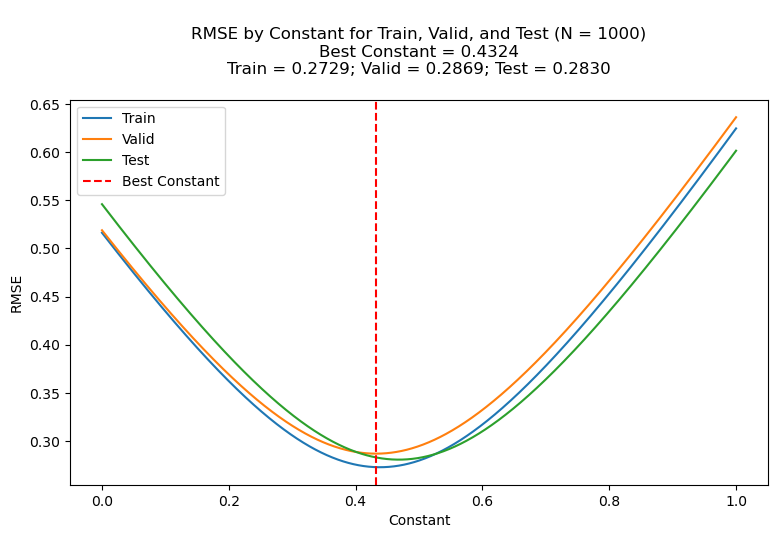

In [9]:
df_tmp = df_constant_score.sort_values(by='score_valid', ascending=True, inplace=False)
flt_constant = df_tmp['constant'].iloc[0]
flt_train = df_tmp['score_train'].iloc[0]
flt_valid = df_tmp['score_valid'].iloc[0]
flt_test = df_tmp['score_test'].iloc[0]
str_title = f"""
RMSE by Constant for Train, Valid, and Test (N = {int_n_constants})
Best Constant = {flt_constant:0.4f}
Train = {flt_train:0.4f}; Valid = {flt_valid:0.4f}; Test = {flt_test:0.4f}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Constant')
ax.set_ylabel('RMSE')
# train
ax.plot(df_constant_score['constant'], df_constant_score['score_train'], label='Train')
# valid
ax.plot(df_constant_score['constant'], df_constant_score['score_valid'], label='Valid')
# test
ax.plot(df_constant_score['constant'], df_constant_score['score_test'], label='Test')
# vertical line
ax.axvline(flt_constant, linestyle='--', color='red', label='Best Constant')
# legend
plt.legend()
# show
plt.show()